# <span style='color: pink'>**NEO4J Graph Database**</span>

1. Connect to Neo4j

In [208]:
from neo4j import GraphDatabase
import pandas as pd

NEO4J_URI = "neo4j://127.0.0.1:7687"
NEO4J_USER = "neo4j"
NEO4J_PASSWORD = "tennisdb"

driver = GraphDatabase.driver(
    NEO4J_URI,
    auth=(NEO4J_USER, NEO4J_PASSWORD)
)

# Quick connectivity test
with driver.session() as session:
    result = session.run("RETURN 'connected' AS status")
    print(result.single()["status"])

# Clear the entire database 
#with driver.session() as session:
    #session.run("MATCH (n) DETACH DELETE n")
    #result = session.run("MATCH (n) RETURN count(n) AS remaining_nodes")
    #print("Database cleared.")
    #print(result.single()["remaining_nodes"])

connected


2. Create constraints

In [209]:
constraints_cypher = [
    """
    CREATE CONSTRAINT player_key_unique IF NOT EXISTS
    FOR (p:Player)
    REQUIRE p.player_key IS UNIQUE
    """,
    """
    CREATE CONSTRAINT tournament_key_unique IF NOT EXISTS
    FOR (t:Tournament)
    REQUIRE t.tourney_key IS UNIQUE
    """,
    """
    CREATE CONSTRAINT match_id_unique IF NOT EXISTS
    FOR (m:Match)
    REQUIRE m.match_id IS UNIQUE
    """,
    """
    CREATE CONSTRAINT ranking_key_unique IF NOT EXISTS
    FOR (r:Ranking)
    REQUIRE r.ranking_key IS UNIQUE
    """
]

with driver.session() as session:
    for q in constraints_cypher:
        session.run(q)

print("Constraints created.")

# Check
with driver.session() as session:
    rows = session.run("SHOW CONSTRAINTS")
    for row in rows:
        print(row["name"])

Constraints created.
match_id_unique
player_key_unique
ranking_key_unique
tournament_key_unique


3. Helper: batch importer (UNWIND)

In [210]:
def run_in_batches(csv_path, query, batch_size=5000):
    """
    Reads a CSV and sends it to Neo4j in batches using UNWIND $rows.
    Does not require Neo4j import folder.
    """
    total = 0

    for chunk in pd.read_csv(csv_path, chunksize=batch_size, low_memory=False):
        rows = chunk.to_dict("records")

        with driver.session() as session:
            def write_batch(tx):
                tx.run(query, rows=rows).consume()

            session.execute_write(write_batch)

        total += len(rows)

        if total % (batch_size * 10) == 0:
            print(f"Imported {total:,} rows from {csv_path}")

    print(f"Done {csv_path}: {total:,} rows")

4. Import Players

In [211]:
PLAYERS_CSV = "data/players_all.csv"

q_players = """
UNWIND $rows AS row
MERGE (p:Player {player_key: row.player_key})
SET
  p.player_id   = toInteger(row.player_id),
  p.player_name = row.player_name,
  p.ioc         = row.ioc,
  p.tour        = row.tour
"""

run_in_batches(PLAYERS_CSV, q_players, batch_size=5000)

Done data/players_all.csv: 3,107 rows


5. Import Tournaments

In [212]:
TOURNEYS_CSV = "data/tournaments_all.csv"

q_tourneys = """
UNWIND $rows AS row
MERGE (t:Tournament {tourney_key: row.tourney_key})
SET
  t.tourney_id    = row.tourney_id,
  t.tourney_name  = row.tourney_name,
  t.tourney_level = row.tourney_level,
  t.surface       = row.surface,
  t.draw_size     = toInteger(row.draw_size),
  t.tour          = row.tour
"""

run_in_batches(TOURNEYS_CSV, q_tourneys, batch_size=2000)

Done data/tournaments_all.csv: 3,084 rows


6. Import Matches + Relationships (Match - Tournament and Match - Player)

In [213]:
MATCHES_CSV = "data/matches_all.csv"

q_matches_and_rels = """
UNWIND $rows AS row

MERGE (m:Match {match_id: row.match_id})
SET
  m.tourney_date = date(row.tourney_date),
  m.round        = row.round,
  m.score        = row.score,
  m.tour         = row.tour

WITH m, row
MATCH (t:Tournament {tourney_key: row.tourney_key})
MERGE (m)-[:BELONGS_TO]->(t)

WITH m, row
MATCH (w:Player {player_key: row.player_winner_key})
MERGE (w)-[:WON]->(m)

WITH m, row
MATCH (l:Player {player_key: row.player_loser_key})
MERGE (l)-[:LOST]->(m)
"""

run_in_batches(MATCHES_CSV, q_matches_and_rels, batch_size=2000)

Imported 20,000 rows from data/matches_all.csv
Imported 40,000 rows from data/matches_all.csv
Imported 60,000 rows from data/matches_all.csv
Imported 80,000 rows from data/matches_all.csv
Imported 100,000 rows from data/matches_all.csv
Imported 120,000 rows from data/matches_all.csv
Done data/matches_all.csv: 127,491 rows


7. Import Rankings + Relationship (Player - Ranking)

In [214]:
RANKINGS_CSV = "data/rankings_all.csv"

q_rankings_and_rels = """
UNWIND $rows AS row

MERGE (r:Ranking {ranking_key: row.ranking_key})
SET
  r.ranking_date = date(row.ranking_date),
  r.rank         = toInteger(row.rank),
  r.points       = toFloat(row.points),
  r.tour         = row.tour

WITH r, row
MATCH (p:Player {player_key: row.player_key})
MERGE (p)-[:HAS_RANKING]->(r)
"""

run_in_batches(RANKINGS_CSV, q_rankings_and_rels, batch_size=5000)

Imported 50,000 rows from data/rankings_all.csv
Imported 100,000 rows from data/rankings_all.csv
Imported 150,000 rows from data/rankings_all.csv
Imported 200,000 rows from data/rankings_all.csv
Imported 250,000 rows from data/rankings_all.csv
Imported 300,000 rows from data/rankings_all.csv
Imported 350,000 rows from data/rankings_all.csv
Imported 400,000 rows from data/rankings_all.csv
Imported 450,000 rows from data/rankings_all.csv
Imported 500,000 rows from data/rankings_all.csv
Imported 550,000 rows from data/rankings_all.csv
Imported 600,000 rows from data/rankings_all.csv
Imported 650,000 rows from data/rankings_all.csv
Imported 700,000 rows from data/rankings_all.csv
Imported 750,000 rows from data/rankings_all.csv
Imported 800,000 rows from data/rankings_all.csv
Imported 850,000 rows from data/rankings_all.csv
Imported 900,000 rows from data/rankings_all.csv
Imported 950,000 rows from data/rankings_all.csv
Imported 1,000,000 rows from data/rankings_all.csv
Imported 1,050,000 

8. Basic Sanity Check

In [215]:
q_checks = [
    ("players",       "MATCH (p:Player) RETURN count(p) AS n"),
    ("tournaments",   "MATCH (t:Tournament) RETURN count(t) AS n"),
    ("matches",       "MATCH (m:Match) RETURN count(m) AS n"),
    ("rankings",      "MATCH (r:Ranking) RETURN count(r) AS n"),
    ("BELONGS_TO",    "MATCH (:Match)-[r:BELONGS_TO]->(:Tournament) RETURN count(r) AS n"),
    ("WON",           "MATCH (:Player)-[r:WON]->(:Match) RETURN count(r) AS n"),
    ("LOST",          "MATCH (:Player)-[r:LOST]->(:Match) RETURN count(r) AS n"),
    ("HAS_RANKING",   "MATCH (:Player)-[r:HAS_RANKING]->(:Ranking) RETURN count(r) AS n"),
]

with driver.session() as session:
    for name, q in q_checks:
        n = session.run(q).single()["n"]
        print(f"{name:12s} : {n}")

players      : 3107
tournaments  : 3084
matches      : 127491
rankings     : 1472325
BELONGS_TO   : 127491
WON          : 127491
LOST         : 127491
HAS_RANKING  : 1472325


9. Helper Function for run Cypher Queries

In [216]:
def cypher_df(query):
    with driver.session() as session:
        result = session.run(query)
        return pd.DataFrame([record.data() for record in result])

#### **Some Integrity Checks**

Check 1: every match belongs to one tournament

In [217]:
q = """
MATCH (m:Match)
WHERE NOT (m)-[:BELONGS_TO]->(:Tournament)
RETURN count(m) AS matches_without_tournament
"""

cypher_df(q)

,matches_without_tournament
0,0


Check 2: every match has one winner

In [218]:
q = """
MATCH (m:Match)
WHERE NOT (:Player)-[:WON]->(m)
RETURN count(m) AS matches_without_winner
"""

cypher_df(q)

,matches_without_winner
0,0


Check 3: every match has one loser

In [219]:
q = """
MATCH (m:Match)
WHERE NOT (:Player)-[:LOST]->(m)
RETURN count(m) AS matches_without_loser
"""

cypher_df(q)

,matches_without_loser
0,0


Check 4: one winner per match

In [220]:
q = """
MATCH (m:Match)<-[r:WON]-(:Player)
WITH m, count(r) AS c
WHERE c <> 1
RETURN count(m) AS problematic_matches
"""

cypher_df(q)

,problematic_matches
0,0


Check 5: one loser per match

In [221]:
q = """
MATCH (m:Match)<-[r:LOST]-(:Player)
WITH m, count(r) AS c
WHERE c <> 1
RETURN count(m) AS problematic_matches
"""

cypher_df(q)

,problematic_matches
0,0


#### **Quick Sample Query**

In [222]:
q = """
MATCH (p:Player)-[:WON]->(m:Match)-[:BELONGS_TO]->(t:Tournament)
RETURN p.player_name AS winner, m.match_id AS match_id, t.tourney_name AS tournament
LIMIT 10
"""

cypher_df(q)

,winner,match_id,tournament
0,Tommy Haas,ATP_2000-301_2000_R32_1,Auckland
1,Juan Balcells,ATP_2000-301_2000_R32_2,Auckland
2,Alberto Martin,ATP_2000-301_2000_R32_3,Auckland
3,Juan Carlos Ferrero,ATP_2000-301_2000_R32_4,Auckland
4,Michael Sell,ATP_2000-301_2000_R32_5,Auckland
5,Michael Chang,ATP_2000-301_2000_R32_6,Auckland
6,Magnus Gustafsson,ATP_2000-301_2000_R32_7,Auckland
7,Thomas Johansson,ATP_2000-301_2000_R32_8,Auckland
8,Sjeng Schalken,ATP_2000-301_2000_R32_9,Auckland
9,Tomas Behrend,ATP_2000-301_2000_R32_10,Auckland


# <span style='color: pink'>**Start GDS**</span>

1. Helper function to run Cypher and get DataFrames

In [223]:
def cypher_df(query):
    with driver.session() as session:
        result = session.run(query)
        return pd.DataFrame([record.data() for record in result])

2. Verify GDS is installed 

In [224]:
cypher_df("""
RETURN gds.version() AS gds_version
""")

,gds_version
0,2.27.0


3. Create the analytical DEFEATED relationship

In [225]:
q_defeated = """
MATCH (winner:Player)-[:WON]->(m:Match)<-[:LOST]-(loser:Player)
WITH winner, loser, count(m) AS wins
MERGE (winner)-[r:DEFEATED]->(loser)
SET r.weight = wins,
    r.tour = winner.tour
"""

with driver.session() as session:
    session.run(q_defeated).consume()

print("DEFEATED relationships created.")

DEFEATED relationships created.


4. Check the new player-vs-player network

In [226]:
# how many player-vs-player edges exist
cypher_df("""
MATCH (:Player)-[r:DEFEATED]->(:Player)
RETURN count(r) AS defeated_edges
""")

,defeated_edges
0,85414


In [227]:
# whether weights were created correctly
cypher_df("""
MATCH (:Player)-[r:DEFEATED]->(:Player)
RETURN min(r.weight) AS min_wins, max(r.weight) AS max_wins, avg(r.weight) AS avg_wins
""")

,min_wins,max_wins,avg_wins
0,1,30,1.492624


In [228]:
# check for self-loops
cypher_df("""
MATCH (p:Player)-[:DEFEATED]->(p)
RETURN count(*) AS self_loops
""")

,self_loops
0,0


In [229]:
# confirm that atp player do not connect to wta player
cypher_df("""
MATCH (p1:Player)-[:DEFEATED]->(p2:Player)
WHERE p1.tour <> p2.tour
RETURN count(*) AS cross_tour_edges
""")

,cross_tour_edges
0,0


5. Create separate ATP and WTA projected graphs

ATP Projection:

In [230]:
# Drop if it already exists, ignore error if it doesn't
with driver.session() as session:
    session.run("CALL gds.graph.drop('atp_net', false) YIELD graphName")

cypher_df("""
MATCH (p1:Player)-[r:DEFEATED]->(p2:Player)
WHERE p1.tour = "ATP" AND p2.tour = "ATP"
WITH gds.graph.project(
  'atp_net',
  p1,
  p2,
  { relationshipProperties: { weight: r.weight } }
) AS g
RETURN g.graphName AS graphName, g.nodeCount AS nodeCount, g.relationshipCount AS relationshipCount
""")


,graphName,nodeCount,relationshipCount
0,atp_net,1598,44082


WTA Projection:

In [231]:
# Drop if it already exists, ignore error if it doesn't
with driver.session() as session:
    session.run("CALL gds.graph.drop('wta_net', false) YIELD graphName")

cypher_df("""
MATCH (p1:Player)-[r:DEFEATED]->(p2:Player)
WHERE p1.tour = "WTA" AND p2.tour = "WTA"
WITH gds.graph.project(
  'wta_net',
  p1,
  p2,
  { relationshipProperties: { weight: r.weight } }
) AS g
RETURN g.graphName AS graphName, g.nodeCount AS nodeCount, g.relationshipCount AS relationshipCount
""")

,graphName,nodeCount,relationshipCount
0,wta_net,1509,41332


In [232]:
cypher_df("""
CALL gds.graph.list()
YIELD graphName, nodeCount, relationshipCount
RETURN graphName, nodeCount, relationshipCount
""")

,graphName,nodeCount,relationshipCount
0,wta_net,1509,41332
1,atp_net,1598,44082


# <span style='color: pink'>**GDS Networks Analysis**</span>

In [233]:
# Ensure out_degree is written to nodes before plotting
cypher_df("""
CALL gds.degree.write('atp_net', {
    orientation: 'NATURAL', writeProperty: 'out_degree'
})
YIELD nodePropertiesWritten
""")
cypher_df("""
CALL gds.degree.write('wta_net', {
    orientation: 'NATURAL', writeProperty: 'out_degree'
})
YIELD nodePropertiesWritten
""")

,nodePropertiesWritten
0,1509


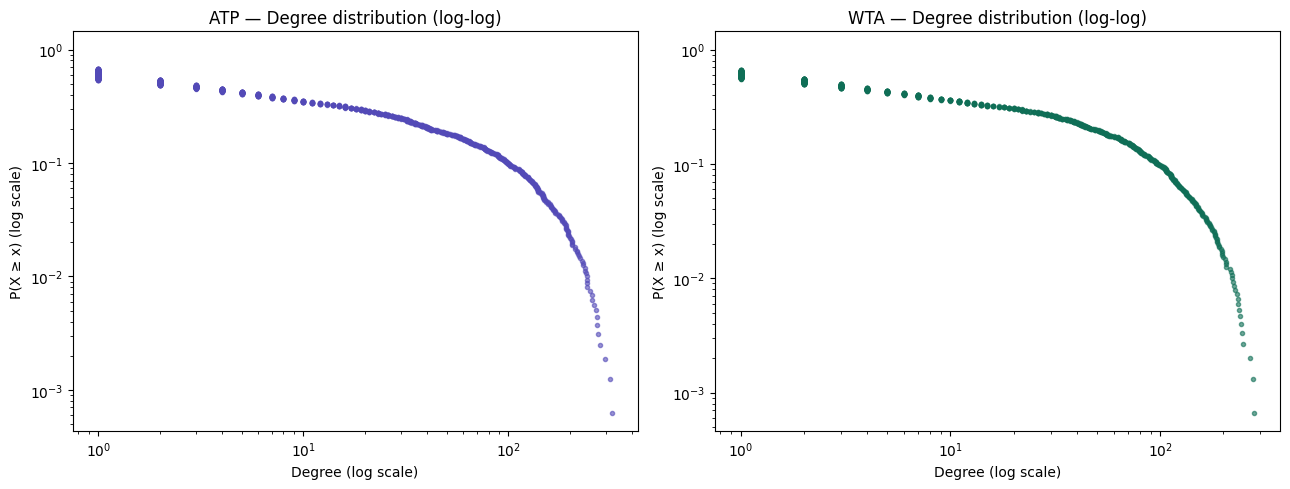

ATP — tail power law exponent: α = 0.092, R² = 0.172
ATP — conclusion: does not follow power law (R² too low)
WTA — tail power law exponent: α = 0.066, R² = 0.072
WTA — conclusion: does not follow power law (R² too low)


In [234]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Pull full degree distributions
atp_degrees = cypher_df("""
MATCH (p:Player {tour: 'ATP'})
WHERE p.out_degree IS NOT NULL
RETURN p.out_degree AS degree
""")['degree'].values

wta_degrees = cypher_df("""
MATCH (p:Player {tour: 'WTA'})
WHERE p.out_degree IS NOT NULL
RETURN p.out_degree AS degree
""")['degree'].values

# Log-log plot to visually check power law behavior
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, degrees, label, color in zip(
    axes,
    [atp_degrees, wta_degrees],
    ['ATP', 'WTA'],
    ['#534AB7', '#0F6E56']
):
    # Compute complementary CDF
    sorted_deg = np.sort(degrees)[::-1]
    ccdf = np.arange(1, len(sorted_deg)+1) / len(sorted_deg)
    
    ax.loglog(sorted_deg, ccdf, 'o', color=color, markersize=3, alpha=0.6)
    ax.set_xlabel('Degree (log scale)')
    ax.set_ylabel('P(X ≥ x) (log scale)')
    ax.set_title(f'{label} — Degree distribution (log-log)')

plt.tight_layout()
plt.savefig('h0_degree_distribution_loglog.png', dpi=150, bbox_inches='tight')
plt.show()

# Fit power law exponent using linear regression on log-log
for degrees, label in [(atp_degrees, 'ATP'), (wta_degrees, 'WTA')]:
    # Only fit the tail (degrees above median) for power law
    tail = degrees[degrees >= np.median(degrees)]
    log_deg = np.log(tail)
    hist, edges = np.histogram(log_deg, bins=15)
    centers = (edges[:-1] + edges[1:]) / 2
    mask = hist > 0
    slope, intercept, r, p, se = stats.linregress(centers[mask], np.log(hist[mask]))
    print(f"{label} — tail power law exponent: α = {-slope:.3f}, R² = {r**2:.3f}")
    print(f"{label} — conclusion: {'weak power law' if r**2 > 0.8 else 'does not follow power law (R² too low)'}")

### **Density**

In [235]:
atp_density = cypher_df("""
MATCH (p:Player {tour: 'ATP'})
WITH count(p) AS n
MATCH (:Player {tour: 'ATP'})-[r:DEFEATED]->(:Player {tour: 'ATP'})
WITH n, count(r) AS e
RETURN n AS nodes, e AS edges,
       round(toFloat(e) / (n * (n-1)), 6) AS density
""")

wta_density = cypher_df("""
MATCH (p:Player {tour: 'WTA'})
WITH count(p) AS n
MATCH (:Player {tour: 'WTA'})-[r:DEFEATED]->(:Player {tour: 'WTA'})
WITH n, count(r) AS e
RETURN n AS nodes, e AS edges,
       round(toFloat(e) / (n * (n-1)), 6) AS density
""")

print("ATP network:")
print(atp_density.to_string(index=False))
print("\nWTA network:")
print(wta_density.to_string(index=False))

ATP network:
 nodes  edges  density
  1598  44082 0.017273

WTA network:
 nodes  edges  density
  1509  41332 0.018163


### **Average Path Lenght**

In [236]:
# Full version (slow but exact)
atp_path = cypher_df("""
CALL gds.alpha.allShortestPaths.stream('atp_net')
YIELD sourceNodeId, targetNodeId, distance
WHERE distance > 0 AND distance < 9999
RETURN round(avg(distance), 4) AS avg_path_length,
       round(max(distance), 0) AS diameter
""")

wta_path = cypher_df("""
CALL gds.alpha.allShortestPaths.stream('wta_net')
YIELD sourceNodeId, targetNodeId, distance
WHERE distance > 0 AND distance < 9999
RETURN round(avg(distance), 4) AS avg_path_length,
       round(max(distance), 0) AS diameter
""")

print("ATP avg path length:", atp_path['avg_path_length'].values[0])
print("ATP diameter:", atp_path['diameter'].values[0])
print("WTA avg path length:", wta_path['avg_path_length'].values[0])
print("WTA diameter:", wta_path['diameter'].values[0])

Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.FeatureDeprecationWarning} {category: DEPRECATION} {title: This feature is deprecated and will be removed in future versions.} {description: The query used a deprecated procedure. ('gds.alpha.allShortestPaths.stream' has been replaced by 'gds.allShortestPaths.stream')} {position: line: 2, column: 1, offset: 1} for query: "\nCALL gds.alpha.allShortestPaths.stream('atp_net')\nYIELD sourceNodeId, targetNodeId, distance\nWHERE distance > 0 AND distance < 9999\nRETURN round(avg(distance), 4) AS avg_path_length,\n       round(max(distance), 0) AS diameter\n"
Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.FeatureDeprecationWarning} {category: DEPRECATION} {title: This feature is deprecated and will be removed in future versions.} {description: The query used a deprecated procedure. ('gds.alpha.allShortestPaths.stream' has been replaced by 'gd

ATP avg path length: 2.9071
ATP diameter: 7.0
WTA avg path length: 2.8998
WTA diameter: 7.0


## **H1 - Dominance Concentration**

### **Out-degree + Gini**

ATP Gini (out-degree): 0.7824
WTA Gini (out-degree): 0.7666

ATP Top 10:
           player  out_degree
    Roger Federer       319.0
     Rafael Nadal       312.0
   Novak Djokovic       294.0
  Richard Gasquet       280.0
Fernando Verdasco       274.0
  Feliciano Lopez       271.0
     Gael Monfils       271.0
     David Ferrer       266.0
    Tommy Robredo       260.0
      Marin Cilic       256.0

WTA Top 10:
             player  out_degree
     Venus Williams       281.0
    Serena Williams       277.0
Svetlana Kuznetsova       268.0
  Victoria Azarenka       249.0
     Vera Zvonareva       245.0
    Jelena Jankovic       242.0
Francesca Schiavone       240.0
       Alize Cornet       238.0
    Maria Sharapova       235.0
 Caroline Wozniacki       235.0


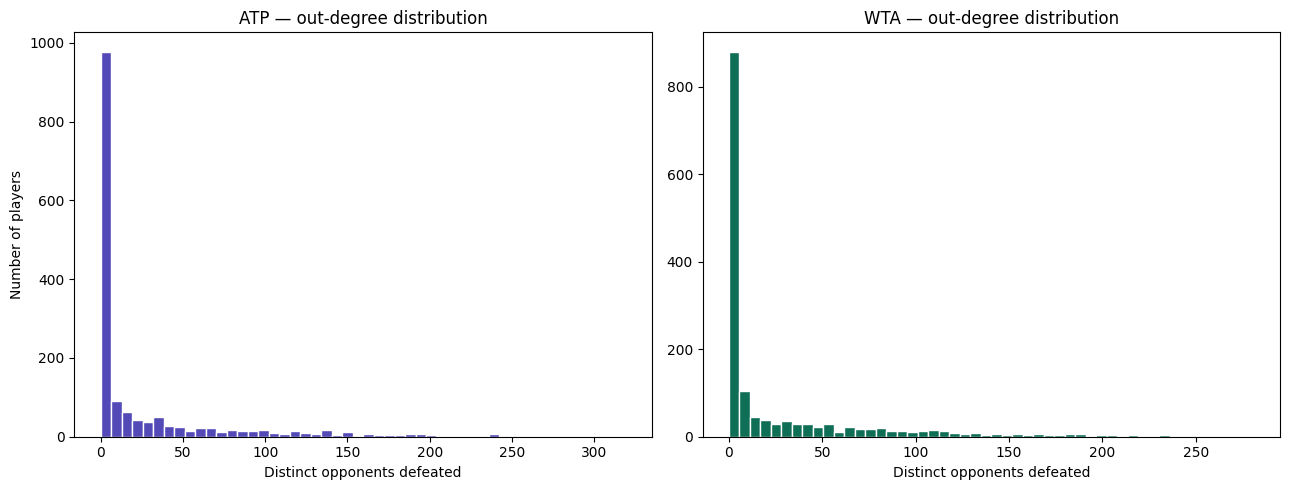

In [237]:
import numpy as np
import matplotlib.pyplot as plt

def gini(arr):
    arr = np.sort(np.array(arr, dtype=float))
    n = len(arr)
    index = np.arange(1, n + 1)
    return (2 * np.sum(index * arr) - (n + 1) * np.sum(arr)) / (n * np.sum(arr))

# Write out-degree to player nodes
cypher_df("""
CALL gds.degree.write('atp_net', {
    orientation: 'NATURAL', writeProperty: 'out_degree'
})
YIELD nodePropertiesWritten
""")
cypher_df("""
CALL gds.degree.write('wta_net', {
    orientation: 'NATURAL', writeProperty: 'out_degree'
})
YIELD nodePropertiesWritten
""")

# Pull results
atp_deg = cypher_df("""
MATCH (p:Player {tour: 'ATP'})
WHERE p.out_degree IS NOT NULL
RETURN p.player_name AS player, p.out_degree AS out_degree
ORDER BY out_degree DESC
""")
wta_deg = cypher_df("""
MATCH (p:Player {tour: 'WTA'})
WHERE p.out_degree IS NOT NULL
RETURN p.player_name AS player, p.out_degree AS out_degree
ORDER BY out_degree DESC
""")

print(f"ATP Gini (out-degree): {gini(atp_deg['out_degree']):.4f}")
print(f"WTA Gini (out-degree): {gini(wta_deg['out_degree']):.4f}")
print()
print("ATP Top 10:")
print(atp_deg.head(10).to_string(index=False))
print()
print("WTA Top 10:")
print(wta_deg.head(10).to_string(index=False))

# Distribution plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(atp_deg['out_degree'], bins=50, color='#534AB7', edgecolor='white')
axes[0].set_title('ATP — out-degree distribution')
axes[0].set_xlabel('Distinct opponents defeated')
axes[0].set_ylabel('Number of players')
axes[1].hist(wta_deg['out_degree'], bins=50, color='#0F6E56', edgecolor='white')
axes[1].set_title('WTA — out-degree distribution')
axes[1].set_xlabel('Distinct opponents defeated')
plt.tight_layout()
plt.savefig('h1_outdegree_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### **PageRank (reversed projection)** 

ATP Gini (PageRank): 0.7029
WTA Gini (PageRank): 0.6898
ATP top-10 PageRank share: 11.19%
WTA top-10 PageRank share: 9.68%

ATP Top 10:
          player  pagerank
   Roger Federer 29.354479
  Novak Djokovic 28.532515
    Rafael Nadal 26.575678
     Andy Murray 16.386349
    David Ferrer 13.711571
   Tomas Berdych 12.182741
    Andy Roddick 11.831814
   Stan Wawrinka 11.503421
  Lleyton Hewitt 11.091757
Alexander Zverev 10.712743

WTA Top 10:
             player  pagerank
    Serena Williams 20.819220
     Venus Williams 16.991021
    Maria Sharapova 14.126286
Svetlana Kuznetsova 13.882796
  Victoria Azarenka 13.288281
      Kim Clijsters 12.936523
 Caroline Wozniacki 12.656557
      Justine Henin 12.600404
      Petra Kvitova 11.641024
    Jelena Jankovic 11.512693


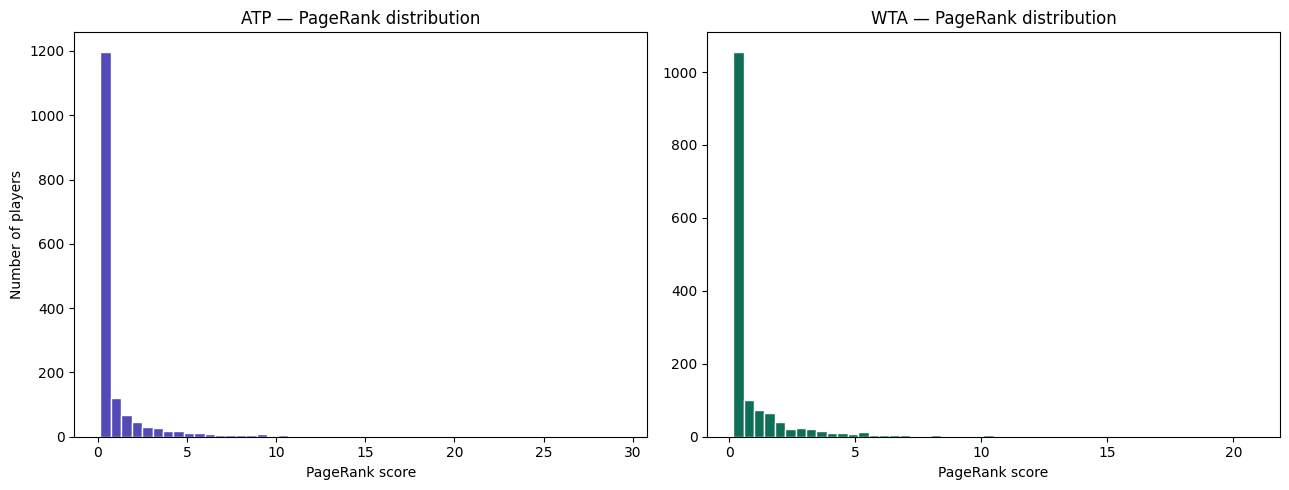

In [238]:
# Drop existing projections and re-create reversed for PageRank
cypher_df("CALL gds.graph.drop('atp_net', false) YIELD graphName")
cypher_df("CALL gds.graph.drop('wta_net', false) YIELD graphName")

cypher_df("""
MATCH (p1:Player)-[r:DEFEATED]->(p2:Player)
WHERE p1.tour = 'ATP' AND p2.tour = 'ATP'
WITH gds.graph.project(
    'atp_net', p2, p1,
    { relationshipProperties: { weight: r.weight } }
) AS g
RETURN g.graphName, g.nodeCount, g.relationshipCount
""")
cypher_df("""
MATCH (p1:Player)-[r:DEFEATED]->(p2:Player)
WHERE p1.tour = 'WTA' AND p2.tour = 'WTA'
WITH gds.graph.project(
    'wta_net', p2, p1,
    { relationshipProperties: { weight: r.weight } }
) AS g
RETURN g.graphName, g.nodeCount, g.relationshipCount
""")

# Run PageRank
cypher_df("""
CALL gds.pageRank.write('atp_net', {
    maxIterations: 20, dampingFactor: 0.85,
    relationshipWeightProperty: 'weight',
    writeProperty: 'pagerank'
})
YIELD nodePropertiesWritten, ranIterations
""")
cypher_df("""
CALL gds.pageRank.write('wta_net', {
    maxIterations: 20, dampingFactor: 0.85,
    relationshipWeightProperty: 'weight',
    writeProperty: 'pagerank'
})
YIELD nodePropertiesWritten, ranIterations
""")

# Pull results
atp_pr = cypher_df("""
MATCH (p:Player {tour: 'ATP'})
WHERE p.pagerank IS NOT NULL
RETURN p.player_name AS player, p.pagerank AS pagerank
ORDER BY pagerank DESC
""")
wta_pr = cypher_df("""
MATCH (p:Player {tour: 'WTA'})
WHERE p.pagerank IS NOT NULL
RETURN p.player_name AS player, p.pagerank AS pagerank
ORDER BY pagerank DESC
""")

# Gini and top-10 share
atp_top10_share = atp_pr.head(10)['pagerank'].sum() / atp_pr['pagerank'].sum() * 100
wta_top10_share = wta_pr.head(10)['pagerank'].sum() / wta_pr['pagerank'].sum() * 100

print(f"ATP Gini (PageRank): {gini(atp_pr['pagerank']):.4f}")
print(f"WTA Gini (PageRank): {gini(wta_pr['pagerank']):.4f}")
print(f"ATP top-10 PageRank share: {atp_top10_share:.2f}%")
print(f"WTA top-10 PageRank share: {wta_top10_share:.2f}%")
print()
print("ATP Top 10:")
print(atp_pr.head(10).to_string(index=False))
print()
print("WTA Top 10:")
print(wta_pr.head(10).to_string(index=False))

# Distribution plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(atp_pr['pagerank'], bins=50, color='#534AB7', edgecolor='white')
axes[0].set_title('ATP — PageRank distribution')
axes[0].set_xlabel('PageRank score')
axes[0].set_ylabel('Number of players')
axes[1].hist(wta_pr['pagerank'], bins=50, color='#0F6E56', edgecolor='white')
axes[1].set_title('WTA — PageRank distribution')
axes[1].set_xlabel('PageRank score')
plt.tight_layout()
plt.savefig('h1_pagerank_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### **Clustering Coefficient** 

In [239]:
# Create undirected projections for clustering coefficient
cypher_df("""
CALL gds.graph.project('atp_net_u', '*', {
    __ALL__: { type: '*', orientation: 'UNDIRECTED' }
})
""")
cypher_df("""
CALL gds.graph.project('wta_net_u', '*', {
    __ALL__: { type: '*', orientation: 'UNDIRECTED' }
})
""")

# Write clustering coefficient using undirected projections
cypher_df("""
CALL gds.localClusteringCoefficient.write('atp_net_u', {
    writeProperty: 'clustering_coeff'
})
YIELD averageClusteringCoefficient, nodePropertiesWritten
""")

cypher_df("""
CALL gds.localClusteringCoefficient.write('wta_net_u', {
    writeProperty: 'clustering_coeff'
})
YIELD averageClusteringCoefficient, nodePropertiesWritten
""")

# Drop temporary undirected projections
cypher_df("CALL gds.graph.drop('atp_net_u')")
cypher_df("CALL gds.graph.drop('wta_net_u')")

# Pull results
atp_cc = cypher_df("""
MATCH (p:Player {tour: 'ATP'})
WHERE p.clustering_coeff IS NOT NULL
RETURN p.player_name AS player, p.clustering_coeff AS cc
""")

wta_cc = cypher_df("""
MATCH (p:Player {tour: 'WTA'})
WHERE p.clustering_coeff IS NOT NULL
RETURN p.player_name AS player, p.clustering_coeff AS cc
""")

print(f"ATP mean clustering coefficient: {atp_cc['cc'].mean():.4f}")
print(f"WTA mean clustering coefficient: {wta_cc['cc'].mean():.4f}")

stat, p = stats.mannwhitneyu(atp_cc['cc'], wta_cc['cc'], alternative='two-sided')
print(f"Mann-Whitney U: stat={stat:.2f}, p={p:.4f}")

Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.FeatureDeprecationWarning} {category: DEPRECATION} {title: This feature is deprecated and will be removed in future versions.} {description: The procedure has a deprecated field. ('schema' returned by 'gds.graph.drop' is deprecated.)} {position: line: 1, column: 1, offset: 0} for query: "CALL gds.graph.drop('atp_net_u')"
Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.FeatureDeprecationWarning} {category: DEPRECATION} {title: This feature is deprecated and will be removed in future versions.} {description: The procedure has a deprecated field. ('schema' returned by 'gds.graph.drop' is deprecated.)} {position: line: 1, column: 1, offset: 0} for query: "CALL gds.graph.drop('wta_net_u')"


ATP mean clustering coefficient: 0.0065
WTA mean clustering coefficient: 0.0138
Mann-Whitney U: stat=1151312.50, p=0.0296


In [240]:
# Win rate of top-ranked players vs everyone outside their tier
df_elite = cypher_df("""
UNWIND ['ATP', 'WTA'] AS tour

// Get all matches with ranking at match time for both players
MATCH (winner:Player {tour: tour})-[:WON]->(m:Match)<-[:LOST]-(loser:Player {tour: tour})

MATCH (winner)-[:HAS_RANKING]->(wr:Ranking)
WHERE abs(duration.inDays(wr.ranking_date, m.tourney_date).days) <= 7

MATCH (loser)-[:HAS_RANKING]->(lr:Ranking)
WHERE abs(duration.inDays(lr.ranking_date, m.tourney_date).days) <= 7

WITH tour, m, winner, loser,
     min(wr.rank) AS winner_rank,
     min(lr.rank) AS loser_rank

// Keep only matches where one player is elite and opponent is NOT in same tier
WITH tour,
     CASE
       WHEN winner_rank = 1   THEN '#1 ranked'
       WHEN winner_rank <= 5  THEN 'Top 5'
       WHEN winner_rank <= 10 THEN 'Top 10'
       ELSE null
     END AS elite_tier,
     winner_rank, loser_rank

WHERE elite_tier IS NOT NULL
  AND loser_rank > 10  // opponent is outside top 10

RETURN tour, elite_tier,
       count(*) AS wins_by_elite

ORDER BY tour, elite_tier
""")

# Total matches played by elite tier (wins + losses)
df_elite_total = cypher_df("""
UNWIND ['ATP', 'WTA'] AS tour

MATCH (elite:Player {tour: tour})-[:WON|LOST]->(m:Match)
MATCH (m)<-[:WON|LOST]-(opp:Player {tour: tour})
WHERE opp <> elite

MATCH (elite)-[:HAS_RANKING]->(er:Ranking)
WHERE abs(duration.inDays(er.ranking_date, m.tourney_date).days) <= 7

MATCH (opp)-[:HAS_RANKING]->(or2:Ranking)
WHERE abs(duration.inDays(or2.ranking_date, m.tourney_date).days) <= 7

WITH tour, m, elite, opp,
     min(er.rank) AS elite_rank,
     min(or2.rank) AS opp_rank

WITH tour,
     CASE
       WHEN elite_rank = 1   THEN '#1 ranked'
       WHEN elite_rank <= 5  THEN 'Top 5'
       WHEN elite_rank <= 10 THEN 'Top 10'
       ELSE null
     END AS elite_tier,
     elite_rank, opp_rank,
     CASE WHEN (elite)-[:WON]->(m) THEN 1 ELSE 0 END AS won

WHERE elite_tier IS NOT NULL AND opp_rank > 10

RETURN tour, elite_tier,
       count(*) AS total_matches,
       sum(won) AS wins,
       round(toFloat(sum(won)) / count(*) * 100, 2) AS win_rate

ORDER BY tour, elite_tier
""")

print(df_elite_total)

  tour elite_tier  total_matches  wins  win_rate
0  ATP  #1 ranked           1338  1200     89.69
1  ATP     Top 10           6631  4969     74.94
2  ATP      Top 5           5340  4365     81.74
3  WTA  #1 ranked           1164  1022     87.80
4  WTA     Top 10           5547  4110     74.09
5  WTA      Top 5           4466  3583     80.23


In [241]:
from scipy.stats import spearmanr

# Pull full PageRank scores (already written to nodes in cell 55)
df_pr_all = cypher_df("""
MATCH (p:Player)
WHERE p.pagerank IS NOT NULL
RETURN p.player_name AS player,
       p.tour        AS tour,
       p.pagerank    AS pagerank
""")

# Get each player's best-ever official rank
df_best_rank = cypher_df("""
MATCH (p:Player)-[:HAS_RANKING]->(r:Ranking)
RETURN p.player_name AS player,
       p.tour        AS tour,
       min(r.rank)   AS best_rank
""")

# Merge
df_validation = df_pr_all.merge(
    df_best_rank, on=['player', 'tour'], how='inner'
).dropna()

# Spearman correlation — rank 1 is best so we negate
for tour in ['ATP', 'WTA']:
    sub = df_validation[df_validation.tour == tour]
    rho, p = spearmanr(sub['pagerank'], -sub['best_rank'])
    print(f"{tour} — PageRank vs official ranking: ρ = {rho:.3f},  p = {p:.2e}")

ATP — PageRank vs official ranking: ρ = 0.898,  p = 0.00e+00
WTA — PageRank vs official ranking: ρ = 0.908,  p = 0.00e+00


In [242]:
# Check how close rankings are to matches on average
cypher_df("""
MATCH (p:Player)-[:WON]->(m:Match)
MATCH (p)-[:HAS_RANKING]->(r:Ranking)
WITH m, min(abs(duration.inDays(r.ranking_date, m.tourney_date).days)) AS closest_days
RETURN min(closest_days) AS min_gap,
       max(closest_days) AS max_gap,
       avg(closest_days) AS avg_gap
""")

,min_gap,max_gap,avg_gap
0,0,721,0.167766


In [243]:
# --- Elite win rate vs rest using official rankings ---
df_elite = cypher_df("""
UNWIND ['ATP', 'WTA'] AS tour

MATCH (winner:Player {tour: tour})-[:WON]->(m:Match)<-[:LOST]-(loser:Player {tour: tour})

MATCH (winner)-[:HAS_RANKING]->(wr:Ranking)
WHERE abs(duration.inDays(wr.ranking_date, m.tourney_date).days) <= 7

MATCH (loser)-[:HAS_RANKING]->(lr:Ranking)
WHERE abs(duration.inDays(lr.ranking_date, m.tourney_date).days) <= 7

WITH tour, m, winner, loser,
     min(wr.rank) AS winner_rank,
     min(lr.rank) AS loser_rank

WHERE winner_rank <= 10 AND loser_rank > 10

WITH tour,
     CASE
       WHEN winner_rank = 1  THEN '#1 ranked'
       WHEN winner_rank <= 5 THEN 'Top 5'
       ELSE 'Top 10'
     END AS tier,
     count(*) AS wins

RETURN tour, tier, wins
ORDER BY tour, tier
""")

df_elite_total = cypher_df("""
UNWIND ['ATP', 'WTA'] AS tour

MATCH (p1:Player {tour: tour})-[:WON]->(m:Match)<-[:LOST]-(p2:Player {tour: tour})

MATCH (p1)-[:HAS_RANKING]->(r1:Ranking)
WHERE abs(duration.inDays(r1.ranking_date, m.tourney_date).days) <= 7

MATCH (p2)-[:HAS_RANKING]->(r2:Ranking)
WHERE abs(duration.inDays(r2.ranking_date, m.tourney_date).days) <= 7

WITH tour, m, p1, p2,
     min(r1.rank) AS rank_p1,
     min(r2.rank) AS rank_p2

// Count from both sides: top player as winner OR as loser
WITH tour, m,
     CASE WHEN rank_p1 <= 10 AND rank_p2 > 10 THEN rank_p1 ELSE null END AS elite_winner_rank,
     CASE WHEN rank_p2 <= 10 AND rank_p1 > 10 THEN rank_p2 ELSE null END AS elite_loser_rank

WHERE elite_winner_rank IS NOT NULL OR elite_loser_rank IS NOT NULL

WITH tour, m,
     coalesce(elite_winner_rank, elite_loser_rank) AS elite_rank,
     elite_winner_rank IS NOT NULL AS elite_won

WITH tour,
     CASE
       WHEN elite_rank = 1  THEN '#1 ranked'
       WHEN elite_rank <= 5 THEN 'Top 5'
       ELSE 'Top 10'
     END AS tier,
     count(*) AS total_matches,
     sum(CASE WHEN elite_won THEN 1 ELSE 0 END) AS wins

RETURN tour, tier,
       total_matches,
       wins,
       round(toFloat(wins) / total_matches * 100, 2) AS win_rate
ORDER BY tour, tier
""")

print(df_elite_total)

  tour       tier  total_matches  wins  win_rate
0  ATP  #1 ranked           1338  1200     89.69
1  ATP     Top 10           6631  4969     74.94
2  ATP      Top 5           5340  4365     81.74
3  WTA  #1 ranked           1164  1022     87.80
4  WTA     Top 10           5547  4110     74.09
5  WTA      Top 5           4466  3583     80.23


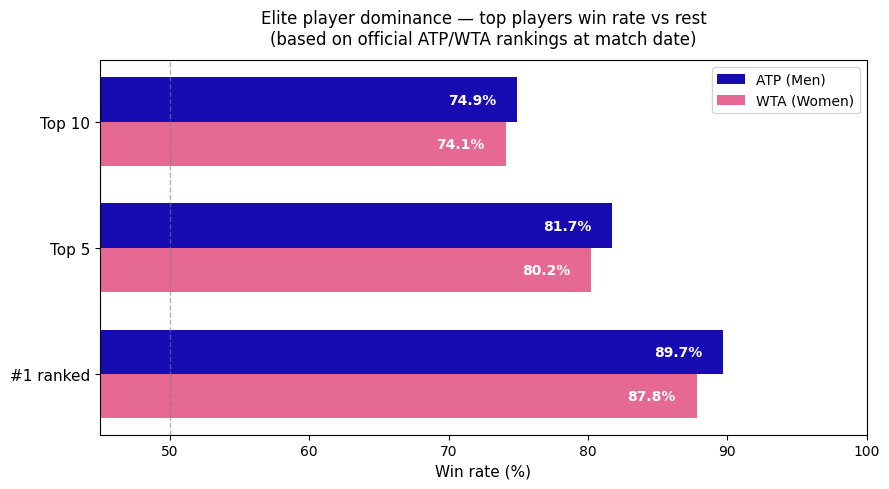

In [244]:
# --- Plot the elite dominance chart ---
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Pivot for plotting
atp_data = df_elite_total[df_elite_total.tour == 'ATP'].set_index('tier')['win_rate']
wta_data = df_elite_total[df_elite_total.tour == 'WTA'].set_index('tier')['win_rate']

tiers = ['#1 ranked', 'Top 5', 'Top 10']
atp_vals = [atp_data.get(t, 0) for t in tiers]
wta_vals = [wta_data.get(t, 0) for t in tiers]

fig, ax = plt.subplots(figsize=(9, 5))
y = np.arange(len(tiers))
h = 0.35

bars_atp = ax.barh(y + h/2, atp_vals, h, color="#180BB1", label='ATP (Men)')
bars_wta = ax.barh(y - h/2, wta_vals, h, color="#E66993", label='WTA (Women)')

ax.axvline(50, color='gray', linestyle='--', linewidth=1, alpha=0.6)

for bar in bars_atp:
    ax.text(bar.get_width() - 1.5, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.1f}%', va='center', ha='right',
            color='white', fontsize=10, fontweight='bold')
for bar in bars_wta:
    ax.text(bar.get_width() - 1.5, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.1f}%', va='center', ha='right',
            color='white', fontsize=10, fontweight='bold')

ax.set_yticks(y)
ax.set_yticklabels(tiers, fontsize=11)
ax.set_xlabel('Win rate (%)', fontsize=11)
ax.set_xlim(45, 100)
ax.set_title('Elite player dominance — top players win rate vs rest\n(based on official ATP/WTA rankings at match date)',
             fontsize=12, pad=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('elite_dominance_official.png', dpi=150, bbox_inches='tight')
plt.show()

## **H2 — Competitive Reciprocity**

In [245]:
# Restore natural orientation for H2 queries
cypher_df("CALL gds.graph.drop('atp_net', false) YIELD graphName")
cypher_df("CALL gds.graph.drop('wta_net', false) YIELD graphName")

cypher_df("""
MATCH (p1:Player)-[r:DEFEATED]->(p2:Player)
WHERE p1.tour = 'ATP' AND p2.tour = 'ATP'
WITH gds.graph.project(
    'atp_net', p1, p2,
    { relationshipProperties: { weight: r.weight } }
) AS g
RETURN g.graphName, g.nodeCount, g.relationshipCount
""")
cypher_df("""
MATCH (p1:Player)-[r:DEFEATED]->(p2:Player)
WHERE p1.tour = 'WTA' AND p2.tour = 'WTA'
WITH gds.graph.project(
    'wta_net', p1, p2,
    { relationshipProperties: { weight: r.weight } }
) AS g
RETURN g.graphName, g.nodeCount, g.relationshipCount
""")

,g.graphName,g.nodeCount,g.relationshipCount
0,wta_net,1509,41332


### **Global reciprocity**

In [246]:
df_reciprocity = cypher_df("""
MATCH (p1:Player)-[:DEFEATED]->(p2:Player)
WHERE p1.tour = p2.tour
WITH p1.tour AS tour,
     count(*) AS total_edges,
     sum(CASE WHEN (p2)-[:DEFEATED]->(p1) THEN 1 ELSE 0 END) AS reciprocated
RETURN tour,
       total_edges,
       reciprocated,
       round(toFloat(reciprocated) / total_edges, 4) AS reciprocity_rate
ORDER BY tour
""")
print(df_reciprocity.to_string(index=False))

tour  total_edges  reciprocated  reciprocity_rate
 ATP        44082         15750            0.3573
 WTA        41332         13598            0.3290


### **Reciprocity by tournament level**

In [247]:
df_rec_level = cypher_df("""
MATCH (p1:Player)-[:WON]->(m:Match)<-[:LOST]-(p2:Player)
MATCH (m)-[:BELONGS_TO]->(t:Tournament)
WHERE p1.tour = p2.tour
WITH p1.tour AS tour,
     t.tourney_level AS level,
     p1, p2
WITH tour, level,
     count(*) AS directed_pairs,
     sum(CASE WHEN (p2)-[:DEFEATED]->(p1) THEN 1 ELSE 0 END) AS reciprocated
RETURN tour, level, directed_pairs, reciprocated,
       round(toFloat(reciprocated) / directed_pairs, 4) AS reciprocity_rate
ORDER BY tour, level
""")
print(df_rec_level.to_string(index=False))

tour level  directed_pairs  reciprocated  reciprocity_rate
 ATP     A           40620         16890            0.4158
 ATP     F             435           342            0.7862
 ATP     G           12534          5225            0.4169
 ATP     M           13899          7924            0.5701
 WTA     F             493           406            0.8235
 WTA     G           12542          4807            0.3833
 WTA     I           14737          4644            0.3151
 WTA     P           10381          5620            0.5414
 WTA    PM            4276          2212            0.5173
 WTA    T1            4619          2045            0.4427
 WTA    T2            4298          2110            0.4909
 WTA    T3            4538          1340            0.2953
 WTA    T4            2894           804            0.2778
 WTA    T5             907           262            0.2889
 WTA     W             318           117            0.3679


### **Annual reciprocity time series**

ATP mean annual reciprocity: 0.0570
WTA mean annual reciprocity: 0.0513


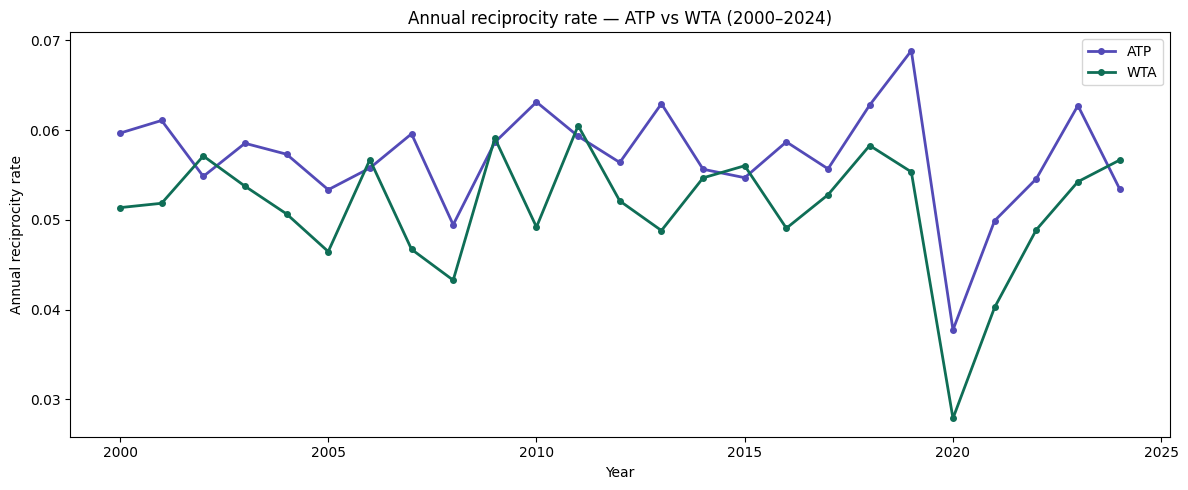

In [248]:
# Total directed pairs per tour per year
total_pairs_by_year = cypher_df("""
MATCH (p1:Player)-[:WON]->(m:Match)<-[:LOST]-(p2:Player)
WHERE p1.tour = p2.tour
WITH p1.tour AS tour, m.tourney_date.year AS year,
     count(DISTINCT [p1.player_key, p2.player_key]) AS total_pairs
RETURN tour, year, total_pairs
ORDER BY tour, year
""")

# Reciprocal pairs per tour per year
reciprocity_by_year = cypher_df("""
MATCH (p1:Player)-[:WON]->(m1:Match)<-[:LOST]-(p2:Player)
MATCH (p2)-[:WON]->(m2:Match)<-[:LOST]-(p1)
WHERE p1.tour = p2.tour
  AND m1.tourney_date.year = m2.tourney_date.year
  AND elementId(p1) < elementId(p2)
WITH p1.tour AS tour,
     m1.tourney_date.year AS year,
     count(DISTINCT [p1.player_key, p2.player_key]) AS reciprocal_pairs
RETURN tour, year, reciprocal_pairs
ORDER BY tour, year
""")

# Merge and compute annual rate
merged = total_pairs_by_year.merge(
    reciprocity_by_year, on=['tour', 'year'], how='left'
)
merged['reciprocal_pairs'] = merged['reciprocal_pairs'].fillna(0)
merged['annual_reciprocity'] = merged['reciprocal_pairs'] / merged['total_pairs']

atp_annual = merged[merged['tour'] == 'ATP']
wta_annual = merged[merged['tour'] == 'WTA']

print(f"ATP mean annual reciprocity: {atp_annual['annual_reciprocity'].mean():.4f}")
print(f"WTA mean annual reciprocity: {wta_annual['annual_reciprocity'].mean():.4f}")

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(atp_annual['year'], atp_annual['annual_reciprocity'],
        color='#534AB7', linewidth=2, marker='o', markersize=4, label='ATP')
ax.plot(wta_annual['year'], wta_annual['annual_reciprocity'],
        color='#0F6E56', linewidth=2, marker='o', markersize=4, label='WTA')
ax.set_xlabel('Year')
ax.set_ylabel('Annual reciprocity rate')
ax.set_title('Annual reciprocity rate — ATP vs WTA (2000–2024)')
ax.legend()
plt.tight_layout()
plt.savefig('h2_annual_reciprocity.png', dpi=150, bbox_inches='tight')
plt.show()

### **Asymmetry index**

In [249]:
df_asymmetry = cypher_df("""
MATCH (p1:Player)-[r1:DEFEATED]->(p2:Player)
WHERE p1.tour = p2.tour AND elementId(p1) < elementId(p2)
OPTIONAL MATCH (p2)-[r2:DEFEATED]->(p1)
WITH p1.tour AS tour,
     abs(r1.weight - coalesce(r2.weight, 0)) AS diff
RETURN tour,
       round(avg(diff), 4) AS avg_asymmetry,
       round(stDev(diff), 4) AS std_asymmetry
ORDER BY tour
""")
print(df_asymmetry.to_string(index=False))

tour  avg_asymmetry  std_asymmetry
 ATP         1.2399         1.1786
 WTA         1.1951         0.9668


## **H3 — Community Structure & Modularity**

### **Louvain**

In [250]:
# Run Louvain on both tours
cypher_df("""
CALL gds.louvain.write('atp_net', {
    writeProperty: 'louvain_community',
    relationshipWeightProperty: 'weight'
})
YIELD communityCount, modularity, modularities
""")

cypher_df("""
CALL gds.louvain.write('wta_net', {
    writeProperty: 'louvain_community',
    relationshipWeightProperty: 'weight'
})
YIELD communityCount, modularity, modularities
""")

# Pull community sizes
atp_communities = cypher_df("""
MATCH (p:Player {tour: 'ATP'})
WHERE p.louvain_community IS NOT NULL
RETURN p.louvain_community AS community, count(p) AS size
ORDER BY size DESC
""")

wta_communities = cypher_df("""
MATCH (p:Player {tour: 'WTA'})
WHERE p.louvain_community IS NOT NULL
RETURN p.louvain_community AS community, count(p) AS size
ORDER BY size DESC
""")

print(f"ATP — communities: {len(atp_communities)}, largest: {atp_communities['size'].max()}, top-5 sizes: {atp_communities['size'].head().tolist()}")
print(f"WTA — communities: {len(wta_communities)}, largest: {wta_communities['size'].max()}, top-5 sizes: {wta_communities['size'].head().tolist()}")

ATP — communities: 471, largest: 463, top-5 sizes: [463, 421, 237, 3, 2]
WTA — communities: 456, largest: 409, top-5 sizes: [409, 345, 284, 3, 2]


### **Modularity Q** 

In [251]:
atp_modularity = cypher_df("""
CALL gds.louvain.stats('atp_net', {
    relationshipWeightProperty: 'weight'
})
YIELD modularity
""")

wta_modularity = cypher_df("""
CALL gds.louvain.stats('wta_net', {
    relationshipWeightProperty: 'weight'
})
YIELD modularity
""")

print(f"ATP modularity Q: {atp_modularity['modularity'].values[0]:.4f}")
print(f"WTA modularity Q: {wta_modularity['modularity'].values[0]:.4f}")

ATP modularity Q: 0.3342
WTA modularity Q: 0.3439


### **Weakly Connected Components**

In [252]:
atp_wcc = cypher_df("""
CALL gds.wcc.stream('atp_net')
YIELD nodeId, componentId
RETURN componentId, count(*) AS size
ORDER BY size DESC
""")

wta_wcc = cypher_df("""
CALL gds.wcc.stream('wta_net')
YIELD nodeId, componentId
RETURN componentId, count(*) AS size
ORDER BY size DESC
""")

print(f"ATP — WCC count: {len(atp_wcc)}, giant component: {atp_wcc['size'].max()}, isolated nodes: {(atp_wcc['size'] == 1).sum()}")
print(f"WTA — WCC count: {len(wta_wcc)}, giant component: {wta_wcc['size'].max()}, isolated nodes: {(wta_wcc['size'] == 1).sum()}")

ATP — WCC count: 1, giant component: 1598, isolated nodes: 0
WTA — WCC count: 1, giant component: 1509, isolated nodes: 0


### **Betweenness Centrality** 

In [253]:
cypher_df("""
CALL gds.betweenness.write('atp_net', { writeProperty: 'betweenness' })
YIELD nodePropertiesWritten
""")

cypher_df("""
CALL gds.betweenness.write('wta_net', { writeProperty: 'betweenness' })
YIELD nodePropertiesWritten
""")

atp_btw = cypher_df("""
MATCH (p:Player {tour: 'ATP'})
WHERE p.betweenness IS NOT NULL
RETURN p.player_name AS player, p.betweenness AS betweenness
ORDER BY betweenness DESC LIMIT 15
""")

wta_btw = cypher_df("""
MATCH (p:Player {tour: 'WTA'})
WHERE p.betweenness IS NOT NULL
RETURN p.player_name AS player, p.betweenness AS betweenness
ORDER BY betweenness DESC LIMIT 15
""")

print("ATP top bridges:"); print(atp_btw.to_string(index=False))
print("\nWTA top bridges:"); print(wta_btw.to_string(index=False))

ATP top bridges:
               player  betweenness
      Feliciano Lopez 52179.074265
      Richard Gasquet 47046.374391
        Fabio Fognini 39114.075856
    Fernando Verdasco 38771.988183
      Mikhail Youzhny 36150.589077
        Stan Wawrinka 35349.243635
         Gael Monfils 33462.498669
         Ivo Karlovic 28329.083784
        Roger Federer 27650.490520
     Adrian Mannarino 26999.772184
        Tommy Robredo 26723.856926
Philipp Kohlschreiber 25573.466027
         David Ferrer 25145.427398
    Nikolay Davydenko 24761.906408
        Andreas Seppi 24257.335512

WTA top bridges:
                 player  betweenness
    Francesca Schiavone 34013.459993
           Alize Cornet 33316.239924
        Klara Koukalova 30958.971676
          Tatjana Maria 29771.841235
         Sorana Cirstea 28661.231383
         Vera Zvonareva 27743.412967
    Svetlana Kuznetsova 27579.778421
         Venus Williams 26548.136173
     Daniela Hantuchova 26447.561856
        Jelena Jankovic 25528.79154

### **PageRank top-10 betweenness rank check** 

In [254]:
# Check where the top-10 PageRank players rank in betweenness
atp_pr_top10 = set(atp_pr.head(10)['player'])
wta_pr_top10 = set(wta_pr.head(10)['player'])

atp_btw_full = cypher_df("""
MATCH (p:Player {tour: 'ATP'})
WHERE p.betweenness IS NOT NULL
RETURN p.player_name AS player, p.betweenness AS betweenness
ORDER BY betweenness DESC
""")
atp_btw_full['rank_btw'] = range(1, len(atp_btw_full)+1)

wta_btw_full = cypher_df("""
MATCH (p:Player {tour: 'WTA'})
WHERE p.betweenness IS NOT NULL
RETURN p.player_name AS player, p.betweenness AS betweenness
ORDER BY betweenness DESC
""")
wta_btw_full['rank_btw'] = range(1, len(wta_btw_full)+1)

print("ATP — PageRank top-10 betweenness ranks:")
print(atp_btw_full[atp_btw_full['player'].isin(atp_pr_top10)][['player','rank_btw']])
print("\nWTA — PageRank top-10 betweenness ranks:")
print(wta_btw_full[wta_btw_full['player'].isin(wta_pr_top10)][['player','rank_btw']])

ATP — PageRank top-10 betweenness ranks:
               player  rank_btw
5       Stan Wawrinka         6
8       Roger Federer         9
12       David Ferrer        13
19     Novak Djokovic        20
28        Andy Murray        29
30       Rafael Nadal        31
43     Lleyton Hewitt        44
63      Tomas Berdych        64
80       Andy Roddick        81
143  Alexander Zverev       144

WTA — PageRank top-10 betweenness ranks:
                  player  rank_btw
6    Svetlana Kuznetsova         7
7         Venus Williams         8
9        Jelena Jankovic        10
17     Victoria Azarenka        18
25         Petra Kvitova        26
35       Serena Williams        36
39    Caroline Wozniacki        40
69       Maria Sharapova        70
119        Kim Clijsters       120
174        Justine Henin       175


### **Spearman PageRank vs Betweenness** 

In [255]:
from scipy.stats import spearmanr

atp_merged_btw = atp_pr.merge(atp_btw_full, on='player')
wta_merged_btw = wta_pr.merge(wta_btw_full, on='player')

rho_atp, p_atp = spearmanr(atp_merged_btw['pagerank'], atp_merged_btw['betweenness'])
rho_wta, p_wta = spearmanr(wta_merged_btw['pagerank'], wta_merged_btw['betweenness'])

print(f"ATP — PageRank vs Betweenness: ρ = {rho_atp:.3f}, p = {p_atp:.2e}")
print(f"WTA — PageRank vs Betweenness: ρ = {rho_wta:.3f}, p = {p_wta:.2e}")

ATP — PageRank vs Betweenness: ρ = 0.970, p = 0.00e+00
WTA — PageRank vs Betweenness: ρ = 0.970, p = 0.00e+00


In [256]:
# Compute the gap between PageRank rank and betweenness rank for top-10 players
atp_pr_ranked = atp_pr.reset_index(drop=True)
atp_pr_ranked['rank_pr'] = range(1, len(atp_pr_ranked)+1)

wta_pr_ranked = wta_pr.reset_index(drop=True)
wta_pr_ranked['rank_pr'] = range(1, len(wta_pr_ranked)+1)

atp_top10_gap = atp_btw_full[atp_btw_full['player'].isin(atp_pr_top10)][['player','rank_btw']].copy()
atp_top10_gap = atp_top10_gap.merge(atp_pr_ranked[['player','rank_pr']], on='player')
atp_top10_gap['gap'] = atp_top10_gap['rank_btw'] - atp_top10_gap['rank_pr']

wta_top10_gap = wta_btw_full[wta_btw_full['player'].isin(wta_pr_top10)][['player','rank_btw']].copy()
wta_top10_gap = wta_top10_gap.merge(wta_pr_ranked[['player','rank_pr']], on='player')
wta_top10_gap['gap'] = wta_top10_gap['rank_btw'] - wta_top10_gap['rank_pr']

print("ATP top-10 — PageRank vs Betweenness rank gap:")
print(atp_top10_gap[['player','rank_pr','rank_btw','gap']].sort_values('rank_pr').to_string(index=False))
print(f"\nATP mean gap: {atp_top10_gap['gap'].mean():.1f}")

print("\nWTA top-10 — PageRank vs Betweenness rank gap:")
print(wta_top10_gap[['player','rank_pr','rank_btw','gap']].sort_values('rank_pr').to_string(index=False))
print(f"\nWTA mean gap: {wta_top10_gap['gap'].mean():.1f}")

ATP top-10 — PageRank vs Betweenness rank gap:
          player  rank_pr  rank_btw  gap
   Roger Federer        1         9    8
  Novak Djokovic        2        20   18
    Rafael Nadal        3        31   28
     Andy Murray        4        29   25
    David Ferrer        5        13    8
   Tomas Berdych        6        64   58
    Andy Roddick        7        81   74
   Stan Wawrinka        8         6   -2
  Lleyton Hewitt        9        44   35
Alexander Zverev       10       144  134

ATP mean gap: 38.6

WTA top-10 — PageRank vs Betweenness rank gap:
             player  rank_pr  rank_btw  gap
    Serena Williams        1        36   35
     Venus Williams        2         8    6
    Maria Sharapova        3        70   67
Svetlana Kuznetsova        4         7    3
  Victoria Azarenka        5        18   13
      Kim Clijsters        6       120  114
 Caroline Wozniacki        7        40   33
      Justine Henin        8       175  167
      Petra Kvitova        9        26

In [257]:
from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(atp_top10_gap['gap'], wta_top10_gap['gap'], alternative='two-sided')
print(f"Gap distribution — Mann-Whitney U: stat={stat:.2f}, p={p:.4f}")

Gap distribution — Mann-Whitney U: stat=51.50, p=0.9397


# <span style='color: pink'>**Statistical Testing**</span> 

The following tests assess whether the structural differences observed between 
the ATP and WTA networks are statistically significant. 

### **H1 Statistical Tests**

In [258]:
from scipy import stats

print("=" * 55)
print("H1 — DOMINANCE CONCENTRATION TESTS")
print("=" * 55)

print("\n--- Out-Degree Distribution ---")
stat, p = stats.mannwhitneyu(
    atp_deg['out_degree'], wta_deg['out_degree'],
    alternative='two-sided'
)
print(f"Mann-Whitney U:      stat={stat:.2f},  p={p:.4f}")

stat, p = stats.ks_2samp(
    atp_deg['out_degree'], wta_deg['out_degree']
)
print(f"Kolmogorov-Smirnov:  stat={stat:.4f},  p={p:.4f}")

print("\n--- PageRank Distribution ---")
stat, p = stats.mannwhitneyu(
    atp_pr['pagerank'], wta_pr['pagerank'],
    alternative='two-sided'
)
print(f"Mann-Whitney U:      stat={stat:.2f},  p={p:.4f}")

stat, p = stats.ks_2samp(
    atp_pr['pagerank'], wta_pr['pagerank']
)
print(f"Kolmogorov-Smirnov:  stat={stat:.4f},  p={p:.4f}")

H1 — DOMINANCE CONCENTRATION TESTS

--- Out-Degree Distribution ---
Mann-Whitney U:      stat=1199389.50,  p=0.7970
Kolmogorov-Smirnov:  stat=0.0257,  p=0.6730

--- PageRank Distribution ---
Mann-Whitney U:      stat=1191825.00,  p=0.5717
Kolmogorov-Smirnov:  stat=0.0287,  p=0.5315


### **H2 Statistical Tests**

In [259]:
from statsmodels.stats.proportion import proportions_ztest

print("=" * 55)
print("H2 — RECIPROCITY AND COMPETITIVE BALANCE TESTS")
print("=" * 55)

# Global reciprocity proportion Z-test
print("\n--- Global Reciprocity (Proportion Z-Test) ---")
atp_row = df_reciprocity[df_reciprocity['tour'] == 'ATP'].iloc[0]
wta_row = df_reciprocity[df_reciprocity['tour'] == 'WTA'].iloc[0]

counts = [int(atp_row['reciprocated']), int(wta_row['reciprocated'])]
nobs   = [int(atp_row['total_edges']),  int(wta_row['total_edges'])]
stat, p = proportions_ztest(counts, nobs)
print(f"Z-test (global reciprocity):  stat={stat:.4f},  p={p:.4f}")

# Annual reciprocity Mann-Whitney U
print("\n--- Annual Reciprocity Rate (Mann-Whitney U) ---")
stat, p = stats.mannwhitneyu(
    atp_annual['annual_reciprocity'],
    wta_annual['annual_reciprocity'],
    alternative='two-sided'
)
print(f"Mann-Whitney U:               stat={stat:.2f},  p={p:.4f}")

# Asymmetry index Mann-Whitney U
print("\n--- Asymmetry Index (Mann-Whitney U) ---")
atp_asym = cypher_df("""
MATCH (p1:Player)-[r1:DEFEATED]->(p2:Player)
WHERE p1.tour = 'ATP' AND p2.tour = 'ATP'
  AND elementId(p1) < elementId(p2)
OPTIONAL MATCH (p2)-[r2:DEFEATED]->(p1)
RETURN abs(r1.weight - coalesce(r2.weight, 0)) AS diff
""")
wta_asym = cypher_df("""
MATCH (p1:Player)-[r1:DEFEATED]->(p2:Player)
WHERE p1.tour = 'WTA' AND p2.tour = 'WTA'
  AND elementId(p1) < elementId(p2)
OPTIONAL MATCH (p2)-[r2:DEFEATED]->(p1)
RETURN abs(r1.weight - coalesce(r2.weight, 0)) AS diff
""")
stat, p = stats.mannwhitneyu(
    atp_asym['diff'], wta_asym['diff'],
    alternative='two-sided'
)
print(f"Mann-Whitney U:               stat={stat:.2f},  p={p:.4f}")

H2 — RECIPROCITY AND COMPETITIVE BALANCE TESTS

--- Global Reciprocity (Proportion Z-Test) ---
Z-test (global reciprocity):  stat=8.7016,  p=0.0000

--- Annual Reciprocity Rate (Mann-Whitney U) ---
Mann-Whitney U:               stat=483.00,  p=0.0010

--- Asymmetry Index (Mann-Whitney U) ---
Mann-Whitney U:               stat=241316827.00,  p=0.8571


### **H3 Statistical Tests**

In [260]:
from scipy import stats

stat, p = stats.mannwhitneyu(
    atp_communities['size'],
    wta_communities['size'],
    alternative='two-sided'
)
print(f"Community size distribution — Mann-Whitney U: stat={stat:.2f}, p={p:.4f}")

# Also compute normalized modularity-based Gini for community sizes
print(f"ATP community size Gini: {gini(atp_communities['size']):.4f}")
print(f"WTA community size Gini: {gini(wta_communities['size']):.4f}")

print("\n--- Clustering Coefficient (Mann-Whitney U) ---")
stat, p = stats.mannwhitneyu(
    atp_cc['cc'], wta_cc['cc'],
    alternative='two-sided'
)
print(f"Mann-Whitney U: stat={stat:.2f}, p={p:.4f}")

Community size distribution — Mann-Whitney U: stat=105205.50, p=0.0856
ATP community size Gini: 0.7012
WTA community size Gini: 0.6931

--- Clustering Coefficient (Mann-Whitney U) ---
Mann-Whitney U: stat=1151312.50, p=0.0296


## **Final Summary Table**

In [261]:
print(f"{'Metric':<40} {'ATP':>8} {'WTA':>8}  {'Test':<22} {'p-value':>10}")
print("-" * 95)
# Preliminary
print(f"{'Network density':<40} {'0.0173':>8} {'0.0182':>8}  {'—':<22} {'—':>10}")
print(f"{'Avg path length':<40} {'2.9071':>8} {'2.8998':>8}  {'—':<22} {'—':>10}")
print(f"{'Diameter':<40} {'7':>8} {'7':>8}  {'—':<22} {'—':>10}")
# H1
print(f"{'Out-degree Gini':<40} {'0.7824':>8} {'0.7666':>8}  {'MWU + KS':<22} {'0.797 / 0.673':>10}")
print(f"{'PageRank Gini':<40} {'0.7029':>8} {'0.6898':>8}  {'MWU + KS':<22} {'0.572 / 0.532':>10}")
print(f"{'Top-10 PageRank share':<40} {'11.19%':>8} {'9.68%':>8}  {'—':<22} {'—':>10}")
print(f"{'Clustering coefficient':<40} {'0.0065':>8} {'0.0138':>8}  {'MWU':<22} {'0.0296':>10}")
# H2
print(f"{'Global reciprocity rate':<40} {'0.3573':>8} {'0.3290':>8}  {'Proportion Z':<22} {'< 0.0001':>10}")
print(f"{'Mean annual reciprocity':<40} {'0.0570':>8} {'0.0513':>8}  {'MWU':<22} {'0.0010':>10}")
print(f"{'Asymmetry index':<40} {'1.2399':>8} {'1.1951':>8}  {'MWU':<22} {'0.857':>10}")
# H3
print(f"{'Modularity Q':<40} {'0.3274':>8} {'0.3433':>8}  {'—':<22} {'—':>10}")
print(f"{'Community size Gini':<40} {'0.7028':>8} {'0.6932':>8}  {'MWU':<22} {'0.056':>10}")
print(f"{'WCC components':<40} {'1':>8} {'1':>8}  {'—':<22} {'—':>10}")

Metric                                        ATP      WTA  Test                      p-value
-----------------------------------------------------------------------------------------------
Network density                            0.0173   0.0182  —                               —
Avg path length                            2.9071   2.8998  —                               —
Diameter                                        7        7  —                               —
Out-degree Gini                            0.7824   0.7666  MWU + KS               0.797 / 0.673
PageRank Gini                              0.7029   0.6898  MWU + KS               0.572 / 0.532
Top-10 PageRank share                      11.19%    9.68%  —                               —
Clustering coefficient                     0.0065   0.0138  MWU                        0.0296
Global reciprocity rate                    0.3573   0.3290  Proportion Z             < 0.0001
Mean annual reciprocity                    0.0570   